# [8.1] Activation Patching Refresher

```python
GT_TIER = "GT-1"
EXERCISE_ID = "8_1_activation_patching_refresher"
EXPECTED_RUNTIME = "60-75 minutes for exercises; about 1 minute for the CUDA preflight"
REQUIRES_GPU = True  # the planted learner theorem runs on CPU; full verification includes CUDA
```

## Core Question

Can clean-into-corrupt activation patching recover a causal route we know exactly, while wrong-position donors and off-route patches fail?

**By the end of this notebook, you will have shown that activation patching exactly recovers the planted `source -> query -> answer` route in a deterministic two-hop copy model, because denoising and noising agree on all three route cells while every off-route and wrong-position-donor control scores zero.**

## Learning Objectives

You will:

- turn RED-vs-BLUE behavior into one signed logit-difference metric;
- implement a calibrated recovery fraction where corrupt is 0 and clean is 1;
- build a transparent model organism with an inspectable causal route;
- patch one residual cell without mutating cached activations;
- sweep every layer-position cell in both denoising and noising directions;
- challenge the result with off-route and wrong-position-donor controls;
- produce and interpret a signature heatmap before looking at the real-model preflight.

## Cold Open: Follow The Color

The task has five positions. The token at `source` is copied to `query`, then to `answer`. The clean prompt has RED at `source`; the corrupt prompt swaps RED and BLUE. The model's weights are fixed and visible, so the route is ground truth rather than a story inferred after seeing a plot.

| run | prompt | expected answer |
|---|---|---|
| clean | `<BOS> RED BLUE QUERY ?` | RED |
| corrupt | `<BOS> BLUE RED QUERY ?` | BLUE |

The planted route is `(embed, source) -> (route, query) -> (readout, answer)`. Your patching code does not receive that route. It must rediscover it from interventions.

<details><summary>Common bug - patching the cache in place</summary>

Clone the activation before replacing one cell. Mutating the clean cache makes later patches depend on earlier trials, so an apparently sharp heatmap can be an order-dependent artifact.

</details>

In [1]:
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch as t

chapter = "chapter8_automated_circuits"
section = "part1_activation_patching_refresher"
root_dir = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / chapter).exists())
exercises_dir = root_dir / chapter / "exercises"
section_dir = exercises_dir / section
asset_dir = root_dir / chapter / "instructions" / "assets"
asset_dir.mkdir(parents=True, exist_ok=True)
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))
if str(exercises_dir) not in sys.path:
    sys.path.append(str(exercises_dir))

import part1_activation_patching_refresher.tests as tests

TOK_BOS, TOK_RED, TOK_BLUE, TOK_QUERY, TOK_MASK = range(5)
TOKEN_NAMES = ("<BOS>", "RED", "BLUE", "QUERY", "?")
POSITION_LABELS = ("<BOS>", "source", "distractor", "query", "answer")
LAYER_LABELS = ("embed", "route", "readout")
SOURCE_POS, DISTRACTOR_POS, QUERY_POS, ANSWER_POS = 1, 2, 3, 4
ROUTE_CELLS = ((0, SOURCE_POS), (1, QUERY_POS), (2, ANSWER_POS))

@dataclass(frozen=True)
class ToyRun:
    logits: t.Tensor
    cache: t.Tensor

@dataclass(frozen=True)
class LocalizationReport:
    top_cells: tuple[tuple[int, int], ...]
    route_cells: tuple[tuple[int, int], ...]
    topk_overlap: float
    route_mean: float
    off_route_max: float
    separation: float

def make_copy_task_pair() -> tuple[t.Tensor, t.Tensor]:
    clean = t.tensor([TOK_BOS, TOK_RED, TOK_BLUE, TOK_QUERY, TOK_MASK])
    corrupt = t.tensor([TOK_BOS, TOK_BLUE, TOK_RED, TOK_QUERY, TOK_MASK])
    return clean, corrupt

clean_tokens, corrupt_tokens = make_copy_task_pair()
print("clean:  ", " ".join(TOKEN_NAMES[i] for i in clean_tokens.tolist()), "-> RED")
print("corrupt:", " ".join(TOKEN_NAMES[i] for i in corrupt_tokens.tolist()), "-> BLUE")

clean:   <BOS> RED BLUE QUERY ? -> RED
corrupt: <BOS> BLUE RED QUERY ? -> BLUE


### Exercise - 1. Define the behavioral readout

> **Difficulty:** easy  
> **Importance:** high  
> **Suggested time:** 5 minutes

Implement RED-minus-BLUE logit difference. Keep the sign fixed across clean, corrupt, and patched runs.

<details><summary>Expected output</summary>

`test_answer_logit_diff` passes. Later, clean is `+2.0` and corrupt is `-2.0`.

</details>

<details><summary>Help - first things to check</summary>

Index the final vocabulary axis, subtract negative from positive, then average any batch dimensions. Reject same-token and out-of-range comparisons.

</details>

<details><summary>Interpretation</summary>

A signed metric turns an intervention into evidence about one behavior. Accuracy would be too coarse here: it discards how far the logits move.

</details>

<details><summary>Solution</summary>

```python
def answer_logit_diff(
    logits: t.Tensor,
    *,
    positive_token_id: int = TOK_RED,
    negative_token_id: int = TOK_BLUE,
) -> float:
    if logits.ndim < 1 or logits.shape[-1] == 0:
        raise ValueError("logits must have a nonempty vocabulary dimension.")
    if positive_token_id == negative_token_id:
        raise ValueError("positive_token_id and negative_token_id must differ.")
    if not 0 <= positive_token_id < logits.shape[-1]:
        raise ValueError("positive_token_id is out of range.")
    if not 0 <= negative_token_id < logits.shape[-1]:
        raise ValueError("negative_token_id is out of range.")
    if not t.isfinite(logits).all():
        raise ValueError("logits must be finite.")
    diff = logits[..., positive_token_id] - logits[..., negative_token_id]
    return float(diff.float().mean().item())
```

</details>

In [2]:
def answer_logit_diff(
    logits: t.Tensor,
    *,
    positive_token_id: int = TOK_RED,
    negative_token_id: int = TOK_BLUE,
) -> float:
    if logits.ndim < 1 or logits.shape[-1] == 0:
        raise ValueError("logits must have a nonempty vocabulary dimension.")
    if positive_token_id == negative_token_id:
        raise ValueError("positive_token_id and negative_token_id must differ.")
    if not 0 <= positive_token_id < logits.shape[-1]:
        raise ValueError("positive_token_id is out of range.")
    if not 0 <= negative_token_id < logits.shape[-1]:
        raise ValueError("negative_token_id is out of range.")
    if not t.isfinite(logits).all():
        raise ValueError("logits must be finite.")
    diff = logits[..., positive_token_id] - logits[..., negative_token_id]
    return float(diff.float().mean().item())

tests.test_answer_logit_diff(answer_logit_diff)

All tests in `test_answer_logit_diff` passed!


### Exercise - 2. Calibrate recovery

> **Difficulty:** easy  
> **Importance:** high  
> **Suggested time:** 5 minutes

Implement `(patched - corrupt) / (clean - corrupt)`. This is the denoising convention used in the original ARENA IOI exercises.

<details><summary>Expected output</summary>

`test_recovery_fraction` passes and maps corrupt, midpoint, clean to `0.0, 0.5, 1.0`.

</details>

<details><summary>Help - first things to check</summary>

Compute the signed clean-corrupt gap once. Reject a zero gap rather than dividing by zero.

</details>

<details><summary>Interpretation</summary>

Values outside `[0, 1]` are possible. They mean the intervention overshot or moved opposite the clean behavior; do not clip them.

</details>

<details><summary>Solution</summary>

```python
def recovery_fraction(
    *, clean_metric: float, corrupt_metric: float, patched_metric: float
) -> float:
    values = t.tensor([clean_metric, corrupt_metric, patched_metric], dtype=t.float64)
    if not t.isfinite(values).all():
        raise ValueError("clean, corrupt, and patched metrics must be finite.")
    gap = clean_metric - corrupt_metric
    if gap == 0:
        raise ValueError("clean_metric and corrupt_metric must differ.")
    return float((patched_metric - corrupt_metric) / gap)
```

</details>

In [3]:
def recovery_fraction(
    *, clean_metric: float, corrupt_metric: float, patched_metric: float
) -> float:
    values = t.tensor([clean_metric, corrupt_metric, patched_metric], dtype=t.float64)
    if not t.isfinite(values).all():
        raise ValueError("clean, corrupt, and patched metrics must be finite.")
    gap = clean_metric - corrupt_metric
    if gap == 0:
        raise ValueError("clean_metric and corrupt_metric must differ.")
    return float((patched_metric - corrupt_metric) / gap)

tests.test_recovery_fraction(recovery_fraction)

All tests in `test_recovery_fraction` passed!


### Exercise - 3. Build the exact model organism

> **Difficulty:** medium  
> **Importance:** high  
> **Suggested time:** 12 minutes

Implement three residual stages: embed RED/BLUE as one-hot channels; copy `source` to `query`; copy `query` to `answer`; read RED/BLUE logits from `answer`. Apply a requested patch immediately after its stage.

<details><summary>Expected output</summary>

`test_causal_copy_model_has_exact_ground_truth` and the partial-patch validation test pass. Clean predicts RED with logits `[0,2,0,0,0]`; corrupt predicts BLUE with `[0,0,2,0,0]`.

</details>

<details><summary>Help - first things to check</summary>

Write a small `maybe_patch` helper. Clone before replacing `resid[position]`. Cache all three post-stage residual tensors.

</details>

<details><summary>Interpretation</summary>

Because every operation is visible and deterministic, the causal route is known independently of the patching result. This is the ground-truth anchor later real-model plots lack.

</details>

<details><summary>Solution</summary>

```python
def _validate_copy_tokens(tokens: t.Tensor) -> None:
    if tokens.shape != (len(POSITION_LABELS),):
        raise ValueError(f"tokens must have shape ({len(POSITION_LABELS)},).")
    if tokens.dtype != t.long:
        raise ValueError("tokens must use torch.long ids.")
    if int(tokens[SOURCE_POS]) not in (TOK_RED, TOK_BLUE):
        raise ValueError("source position must contain RED or BLUE.")
    if int(tokens[DISTRACTOR_POS]) not in (TOK_RED, TOK_BLUE):
        raise ValueError("distractor position must contain RED or BLUE.")
    if int(tokens[QUERY_POS]) != TOK_QUERY or int(tokens[ANSWER_POS]) != TOK_MASK:
        raise ValueError("query and answer positions must contain QUERY and ?.")

def run_causal_copy_model(
    tokens: t.Tensor,
    *,
    patch_layer: int | None = None,
    patch_position: int | None = None,
    donor_cache: t.Tensor | None = None,
) -> ToyRun:
    _validate_copy_tokens(tokens)
    patch_requested = patch_layer is not None or patch_position is not None or donor_cache is not None
    if patch_requested:
        if patch_layer is None or patch_position is None or donor_cache is None:
            raise ValueError("patch_layer, patch_position, and donor_cache are required together.")
        if donor_cache.shape != (len(LAYER_LABELS), len(POSITION_LABELS), 2):
            raise ValueError("donor_cache has the wrong shape.")
        if not 0 <= patch_layer < len(LAYER_LABELS):
            raise ValueError("patch_layer is out of range.")
        if not 0 <= patch_position < len(POSITION_LABELS):
            raise ValueError("patch_position is out of range.")

    def maybe_patch(resid: t.Tensor, layer: int) -> t.Tensor:
        if patch_requested and layer == patch_layer:
            resid = resid.clone()
            resid[patch_position] = donor_cache[layer, patch_position]
        return resid

    resid_0 = t.zeros((len(POSITION_LABELS), 2), dtype=t.float32)
    resid_0[tokens == TOK_RED, 0] = 1.0
    resid_0[tokens == TOK_BLUE, 1] = 1.0
    resid_0 = maybe_patch(resid_0, 0)

    resid_1 = resid_0.clone()
    resid_1[QUERY_POS] = resid_0[SOURCE_POS]
    resid_1 = maybe_patch(resid_1, 1)

    resid_2 = resid_1.clone()
    resid_2[ANSWER_POS] = resid_1[QUERY_POS]
    resid_2 = maybe_patch(resid_2, 2)

    cache = t.stack([resid_0, resid_1, resid_2])
    logits = t.zeros(len(TOKEN_NAMES), dtype=t.float32)
    logits[TOK_RED] = 2.0 * resid_2[ANSWER_POS, 0]
    logits[TOK_BLUE] = 2.0 * resid_2[ANSWER_POS, 1]
    return ToyRun(logits=logits, cache=cache)
```

</details>

In [4]:
def _validate_copy_tokens(tokens: t.Tensor) -> None:
    if tokens.shape != (len(POSITION_LABELS),):
        raise ValueError(f"tokens must have shape ({len(POSITION_LABELS)},).")
    if tokens.dtype != t.long:
        raise ValueError("tokens must use torch.long ids.")
    if int(tokens[SOURCE_POS]) not in (TOK_RED, TOK_BLUE):
        raise ValueError("source position must contain RED or BLUE.")
    if int(tokens[DISTRACTOR_POS]) not in (TOK_RED, TOK_BLUE):
        raise ValueError("distractor position must contain RED or BLUE.")
    if int(tokens[QUERY_POS]) != TOK_QUERY or int(tokens[ANSWER_POS]) != TOK_MASK:
        raise ValueError("query and answer positions must contain QUERY and ?.")

def run_causal_copy_model(
    tokens: t.Tensor,
    *,
    patch_layer: int | None = None,
    patch_position: int | None = None,
    donor_cache: t.Tensor | None = None,
) -> ToyRun:
    _validate_copy_tokens(tokens)
    patch_requested = patch_layer is not None or patch_position is not None or donor_cache is not None
    if patch_requested:
        if patch_layer is None or patch_position is None or donor_cache is None:
            raise ValueError("patch_layer, patch_position, and donor_cache are required together.")
        if donor_cache.shape != (len(LAYER_LABELS), len(POSITION_LABELS), 2):
            raise ValueError("donor_cache has the wrong shape.")
        if not 0 <= patch_layer < len(LAYER_LABELS):
            raise ValueError("patch_layer is out of range.")
        if not 0 <= patch_position < len(POSITION_LABELS):
            raise ValueError("patch_position is out of range.")

    def maybe_patch(resid: t.Tensor, layer: int) -> t.Tensor:
        if patch_requested and layer == patch_layer:
            resid = resid.clone()
            resid[patch_position] = donor_cache[layer, patch_position]
        return resid

    resid_0 = t.zeros((len(POSITION_LABELS), 2), dtype=t.float32)
    resid_0[tokens == TOK_RED, 0] = 1.0
    resid_0[tokens == TOK_BLUE, 1] = 1.0
    resid_0 = maybe_patch(resid_0, 0)

    resid_1 = resid_0.clone()
    resid_1[QUERY_POS] = resid_0[SOURCE_POS]
    resid_1 = maybe_patch(resid_1, 1)

    resid_2 = resid_1.clone()
    resid_2[ANSWER_POS] = resid_1[QUERY_POS]
    resid_2 = maybe_patch(resid_2, 2)

    cache = t.stack([resid_0, resid_1, resid_2])
    logits = t.zeros(len(TOKEN_NAMES), dtype=t.float32)
    logits[TOK_RED] = 2.0 * resid_2[ANSWER_POS, 0]
    logits[TOK_BLUE] = 2.0 * resid_2[ANSWER_POS, 1]
    return ToyRun(logits=logits, cache=cache)

tests.test_causal_copy_model_has_exact_ground_truth(run_causal_copy_model)
tests.test_causal_copy_model_rejects_partial_patch_spec(run_causal_copy_model)

All tests in `test_causal_copy_model_has_exact_ground_truth` passed!
All tests in `test_causal_copy_model_rejects_partial_patch_spec` passed!


### Exercise - 4. Patch one residual cell

> **Difficulty:** easy  
> **Importance:** high  
> **Suggested time:** 5 minutes

Implement a clean-into-corrupt intervention at one `(layer, position)` cell. The recipient must be rerun from its input so downstream computation can respond.

<details><summary>Expected output</summary>

`test_patch_residual_cell_is_local_and_non_mutating` passes. Patching `(embed, source)` flips the corrupt answer to RED; `(embed, distractor)` does nothing.

</details>

<details><summary>Help - first things to check</summary>

Call the model with all three patch arguments. Do not edit the donor cache or reuse a partially executed recipient.

</details>

<details><summary>Interpretation</summary>

A successful patch shows sufficiency under this intervention. It does not prove the cell is the only route, which is why we later add noising and controls.

</details>

<details><summary>Solution</summary>

```python
def patch_residual_cell(
    recipient_tokens: t.Tensor,
    donor_cache: t.Tensor,
    *,
    layer: int,
    position: int,
) -> ToyRun:
    return run_causal_copy_model(
        recipient_tokens,
        patch_layer=layer,
        patch_position=position,
        donor_cache=donor_cache,
    )
```

</details>

In [5]:
def patch_residual_cell(
    recipient_tokens: t.Tensor,
    donor_cache: t.Tensor,
    *,
    layer: int,
    position: int,
) -> ToyRun:
    return run_causal_copy_model(
        recipient_tokens,
        patch_layer=layer,
        patch_position=position,
        donor_cache=donor_cache,
    )

tests.test_patch_residual_cell_is_local_and_non_mutating(patch_residual_cell)

All tests in `test_patch_residual_cell_is_local_and_non_mutating` passed!


### Exercise - 5. Sweep clean into corrupt

> **Difficulty:** medium  
> **Importance:** high  
> **Suggested time:** 12 minutes

Run a fresh corrupt forward pass for every layer-position cell, patch the matching clean cache cell, and normalize the patched logit difference.

<details><summary>Expected output</summary>

`test_denoising_sweep_recovers_exact_route` passes. The heatmap has ones only at `(embed, source)`, `(route, query)`, and `(readout, answer)`.

</details>

<details><summary>Help - first things to check</summary>

Use nested loops over three layers and five positions. The optional donor cache will be used for a control in Exercise 7.

</details>

<details><summary>Interpretation</summary>

The moving hot cell is the computation itself moving through positions. This is the same interpretive move as the original IOI residual-stream patching plot.

</details>

<details><summary>Solution</summary>

```python
def denoising_patch_sweep(
    clean_tokens: t.Tensor,
    corrupt_tokens: t.Tensor,
    *,
    donor_cache: t.Tensor | None = None,
) -> t.Tensor:
    clean_run = run_causal_copy_model(clean_tokens)
    corrupt_run = run_causal_copy_model(corrupt_tokens)
    donor_cache = clean_run.cache if donor_cache is None else donor_cache
    clean_metric = answer_logit_diff(clean_run.logits)
    corrupt_metric = answer_logit_diff(corrupt_run.logits)
    scores = t.empty((len(LAYER_LABELS), len(POSITION_LABELS)), dtype=t.float32)
    for layer in range(scores.shape[0]):
        for position in range(scores.shape[1]):
            patched = patch_residual_cell(
                corrupt_tokens, donor_cache, layer=layer, position=position
            )
            scores[layer, position] = recovery_fraction(
                clean_metric=clean_metric,
                corrupt_metric=corrupt_metric,
                patched_metric=answer_logit_diff(patched.logits),
            )
    return scores
```

</details>

In [6]:
def denoising_patch_sweep(
    clean_tokens: t.Tensor,
    corrupt_tokens: t.Tensor,
    *,
    donor_cache: t.Tensor | None = None,
) -> t.Tensor:
    clean_run = run_causal_copy_model(clean_tokens)
    corrupt_run = run_causal_copy_model(corrupt_tokens)
    donor_cache = clean_run.cache if donor_cache is None else donor_cache
    clean_metric = answer_logit_diff(clean_run.logits)
    corrupt_metric = answer_logit_diff(corrupt_run.logits)
    scores = t.empty((len(LAYER_LABELS), len(POSITION_LABELS)), dtype=t.float32)
    for layer in range(scores.shape[0]):
        for position in range(scores.shape[1]):
            patched = patch_residual_cell(
                corrupt_tokens, donor_cache, layer=layer, position=position
            )
            scores[layer, position] = recovery_fraction(
                clean_metric=clean_metric,
                corrupt_metric=corrupt_metric,
                patched_metric=answer_logit_diff(patched.logits),
            )
    return scores

tests.test_denoising_sweep_recovers_exact_route(denoising_patch_sweep)

All tests in `test_denoising_sweep_recovers_exact_route` passed!


### Exercise - 6. Reverse the intervention

> **Difficulty:** medium  
> **Importance:** high  
> **Suggested time:** 10 minutes

Patch corrupt activations into the clean run and measure destroyed clean behavior. A route that is both sufficient and necessary should appear in both directions.

<details><summary>Expected output</summary>

`test_noising_sweep_matches_exact_route` passes, with exact equality to the denoising heatmap.

</details>

<details><summary>Help - first things to check</summary>

Use `(clean_metric - patched_metric) / (clean_metric - corrupt_metric)`. The donor is now the corrupt cache and the recipient is clean.

</details>

<details><summary>Interpretation</summary>

Denoising asks sufficiency; noising asks necessity. Agreement is unusually exact here because the model has one planted route. Real networks need not agree this cleanly.

</details>

<details><summary>Solution</summary>

```python
def noising_patch_sweep(clean_tokens: t.Tensor, corrupt_tokens: t.Tensor) -> t.Tensor:
clean_run = run_causal_copy_model(clean_tokens)
corrupt_run = run_causal_copy_model(corrupt_tokens)
clean_metric = answer_logit_diff(clean_run.logits)
corrupt_metric = answer_logit_diff(corrupt_run.logits)
gap = clean_metric - corrupt_metric
scores = t.empty((len(LAYER_LABELS), len(POSITION_LABELS)), dtype=t.float32)
for layer in range(scores.shape[0]):
    for position in range(scores.shape[1]):
        patched = patch_residual_cell(
            clean_tokens, corrupt_run.cache, layer=layer, position=position
        )
        scores[layer, position] = (
            clean_metric - answer_logit_diff(patched.logits)
        ) / gap
return scores
```

</details>

In [7]:
def noising_patch_sweep(clean_tokens: t.Tensor, corrupt_tokens: t.Tensor) -> t.Tensor:
    clean_run = run_causal_copy_model(clean_tokens)
    corrupt_run = run_causal_copy_model(corrupt_tokens)
    clean_metric = answer_logit_diff(clean_run.logits)
    corrupt_metric = answer_logit_diff(corrupt_run.logits)
    gap = clean_metric - corrupt_metric
    scores = t.empty((len(LAYER_LABELS), len(POSITION_LABELS)), dtype=t.float32)
    for layer in range(scores.shape[0]):
        for position in range(scores.shape[1]):
            patched = patch_residual_cell(
                clean_tokens, corrupt_run.cache, layer=layer, position=position
            )
            scores[layer, position] = (
                clean_metric - answer_logit_diff(patched.logits)
            ) / gap
    return scores

tests.test_noising_sweep_matches_exact_route(noising_patch_sweep)

All tests in `test_noising_sweep_matches_exact_route` passed!


### Exercise - 7. Build a wrong-position donor control

> **Difficulty:** easy  
> **Importance:** high  
> **Suggested time:** 7 minutes

Repeat the clean distractor activation across all positions, preserving cache shape. This asks whether a shape-compatible but semantically wrong donor can create a convincing heatmap.

<details><summary>Expected output</summary>

`test_wrong_position_donor_control_fails` passes and every recovery score is exactly `0.0`.

</details>

<details><summary>Help - first things to check</summary>

Select `DISTRACTOR_POS` with a length-one slice, expand it to the cache shape, and clone the expanded view.

</details>

<details><summary>Interpretation</summary>

The control rules out the claim that any clean-looking activation or tensor replacement is enough. Correspondence between donor and recipient matters.

</details>

<details><summary>Solution</summary>

```python
def make_wrong_position_donor(clean_cache: t.Tensor) -> t.Tensor:
expected_shape = (len(LAYER_LABELS), len(POSITION_LABELS), 2)
if clean_cache.shape != expected_shape:
    raise ValueError(f"clean_cache must have shape {expected_shape}.")
distractor = clean_cache[:, DISTRACTOR_POS : DISTRACTOR_POS + 1]
return distractor.expand_as(clean_cache).clone()
```

</details>

In [8]:
def make_wrong_position_donor(clean_cache: t.Tensor) -> t.Tensor:
    expected_shape = (len(LAYER_LABELS), len(POSITION_LABELS), 2)
    if clean_cache.shape != expected_shape:
        raise ValueError(f"clean_cache must have shape {expected_shape}.")
    distractor = clean_cache[:, DISTRACTOR_POS : DISTRACTOR_POS + 1]
    return distractor.expand_as(clean_cache).clone()

tests.test_wrong_position_donor_control_fails(make_wrong_position_donor, denoising_patch_sweep)

All tests in `test_wrong_position_donor_control_fails` passed!


### Exercise - 8. Score localization and make the signature result

> **Difficulty:** medium  
> **Importance:** high  
> **Suggested time:** 12 minutes

Rank all cells, compare the top three with the planted route, and quantify route mean minus maximum off-route recovery. Then render denoising, noising, wrong-donor, and metric panels.

<details><summary>Expected output</summary>

`top-k overlap = 1.0`, `route mean = 1.0`, `off-route max = 0.0`, `separation = 1.0`; all signature-contract tests pass.

</details>

<details><summary>Help - first things to check</summary>

Flatten only for ranking, then map flat indices back with division and modulo. Use a boolean route mask for route and off-route aggregates.

</details>

<details><summary>Interpretation</summary>

A convincing localization result needs both a positive route and failed controls. The plot earns its interpretation because the route was specified before the sweep.

</details>

<details><summary>Solution</summary>

```python
def localization_report(
    patch_scores: t.Tensor,
    *,
    route_cells: tuple[tuple[int, int], ...] = ROUTE_CELLS,
) -> LocalizationReport:
    expected_shape = (len(LAYER_LABELS), len(POSITION_LABELS))
    if patch_scores.shape != expected_shape:
        raise ValueError(f"patch_scores must have shape {expected_shape}.")
    if not t.isfinite(patch_scores).all():
        raise ValueError("patch_scores must be finite.")
    if not route_cells:
        raise ValueError("route_cells must be nonempty.")
    flat = patch_scores.flatten()
    for layer, position in route_cells:
        if not 0 <= layer < patch_scores.shape[0] or not 0 <= position < patch_scores.shape[1]:
            raise ValueError("route cell is out of range.")
    top_indices = flat.topk(k=len(route_cells)).indices.tolist()
    top_cells = tuple((i // patch_scores.shape[1], i % patch_scores.shape[1]) for i in top_indices)
    route_mask = t.zeros_like(patch_scores, dtype=t.bool)
    for cell in route_cells:
        route_mask[cell] = True
    topk_overlap = len(set(top_cells) & set(route_cells)) / len(route_cells)
    route_mean = float(patch_scores[route_mask].mean().item())
    off_route_max = float(patch_scores[~route_mask].max().item())
    return LocalizationReport(
        top_cells=top_cells,
        route_cells=route_cells,
        topk_overlap=topk_overlap,
        route_mean=route_mean,
        off_route_max=off_route_max,
        separation=route_mean - off_route_max,
    )
```

</details>

All tests in `test_localization_report_recovers_route` passed!
All tests in `test_localization_report_exposes_false_positive` passed!
All tests in `test_signature_contract` passed!


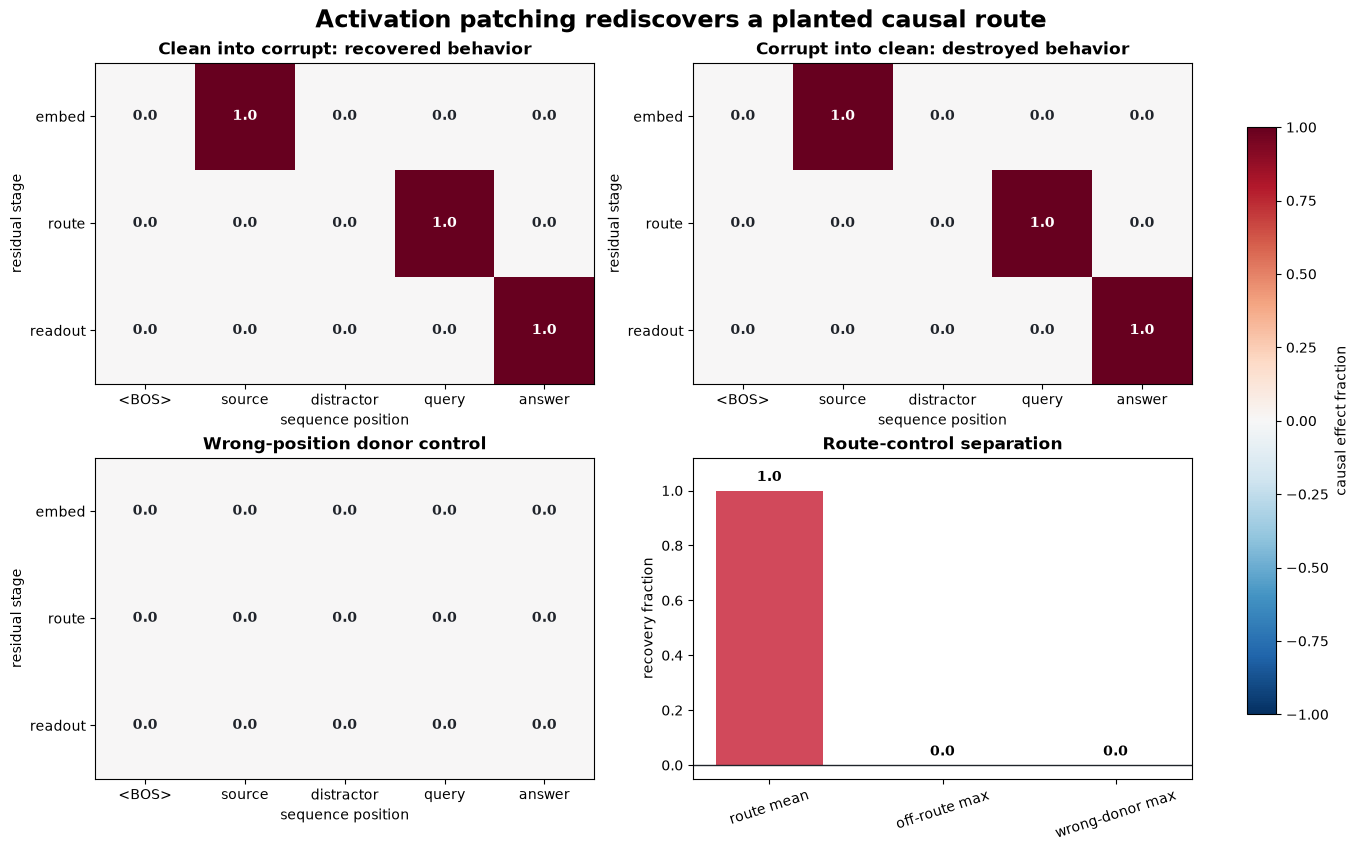

top-k overlap: 1.0
route/off-route separation: 1.0
wrong-position donor max: 0.0
denoising/noising max error: 0.0


In [9]:
def localization_report(
    patch_scores: t.Tensor,
    *,
    route_cells: tuple[tuple[int, int], ...] = ROUTE_CELLS,
) -> LocalizationReport:
    expected_shape = (len(LAYER_LABELS), len(POSITION_LABELS))
    if patch_scores.shape != expected_shape:
        raise ValueError(f"patch_scores must have shape {expected_shape}.")
    if not t.isfinite(patch_scores).all():
        raise ValueError("patch_scores must be finite.")
    if not route_cells:
        raise ValueError("route_cells must be nonempty.")
    flat = patch_scores.flatten()
    for layer, position in route_cells:
        if not 0 <= layer < patch_scores.shape[0] or not 0 <= position < patch_scores.shape[1]:
            raise ValueError("route cell is out of range.")
    top_indices = flat.topk(k=len(route_cells)).indices.tolist()
    top_cells = tuple((i // patch_scores.shape[1], i % patch_scores.shape[1]) for i in top_indices)
    route_mask = t.zeros_like(patch_scores, dtype=t.bool)
    for cell in route_cells:
        route_mask[cell] = True
    topk_overlap = len(set(top_cells) & set(route_cells)) / len(route_cells)
    route_mean = float(patch_scores[route_mask].mean().item())
    off_route_max = float(patch_scores[~route_mask].max().item())
    return LocalizationReport(
        top_cells=top_cells,
        route_cells=route_cells,
        topk_overlap=topk_overlap,
        route_mean=route_mean,
        off_route_max=off_route_max,
        separation=route_mean - off_route_max,
    )

tests.test_localization_report_recovers_route(localization_report)
tests.test_localization_report_exposes_false_positive(localization_report)

def run_toy_signature_result() -> dict:
    clean_run = run_causal_copy_model(clean_tokens)
    corrupt_run = run_causal_copy_model(corrupt_tokens)
    denoising = denoising_patch_sweep(clean_tokens, corrupt_tokens)
    noising = noising_patch_sweep(clean_tokens, corrupt_tokens)
    wrong_donor = make_wrong_position_donor(clean_run.cache)
    donor_control = denoising_patch_sweep(
        clean_tokens, corrupt_tokens, donor_cache=wrong_donor
    )
    report = localization_report(denoising)
    return {
        "claim": "Activation patching exactly recovers the planted source-to-query-to-answer route.",
        "clean_metric": answer_logit_diff(clean_run.logits),
        "corrupt_metric": answer_logit_diff(corrupt_run.logits),
        "denoising_scores": denoising.tolist(),
        "noising_scores": noising.tolist(),
        "wrong_position_donor_scores": donor_control.tolist(),
        "top_cells": [list(cell) for cell in report.top_cells],
        "route_cells": [list(cell) for cell in report.route_cells],
        "topk_overlap": report.topk_overlap,
        "route_mean": report.route_mean,
        "off_route_max": report.off_route_max,
        "separation": report.separation,
        "wrong_position_donor_max": float(donor_control.abs().max().item()),
        "denoising_noising_max_error": float((denoising - noising).abs().max().item()),
        "exact_ground_truth_passed": bool(
            report.topk_overlap == 1.0
            and report.separation == 1.0
            and donor_control.abs().max().item() == 0.0
            and t.equal(denoising, noising)
        ),
    }

signature = run_toy_signature_result()
tests.test_signature_contract(run_toy_signature_result)

denoising = t.tensor(signature["denoising_scores"])
noising = t.tensor(signature["noising_scores"])
wrong_donor = t.tensor(signature["wrong_position_donor_scores"])

fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.4), constrained_layout=True)
heatmaps = [
    (denoising, "Clean into corrupt: recovered behavior"),
    (noising, "Corrupt into clean: destroyed behavior"),
    (wrong_donor, "Wrong-position donor control"),
]
for ax, (matrix, title) in zip(axes.flat[:3], heatmaps):
    image = ax.imshow(matrix, cmap="RdBu_r", vmin=-1.0, vmax=1.0, aspect="auto")
    ax.set_xticks(range(len(POSITION_LABELS)), POSITION_LABELS)
    ax.set_yticks(range(len(LAYER_LABELS)), LAYER_LABELS)
    ax.set_xlabel("sequence position")
    ax.set_ylabel("residual stage")
    ax.set_title(title, fontsize=12, fontweight="bold")
    for layer in range(matrix.shape[0]):
        for position in range(matrix.shape[1]):
            value = float(matrix[layer, position])
            ax.text(position, layer, f"{value:.1f}", ha="center", va="center", color="white" if abs(value) > 0.55 else "#20242b", fontweight="bold")
fig.colorbar(image, ax=axes.flat[:3], shrink=0.82, label="causal effect fraction")

metric_names = ["route mean", "off-route max", "wrong-donor max"]
metric_values = [signature["route_mean"], signature["off_route_max"], signature["wrong_position_donor_max"]]
colors = ["#d1495b", "#4f6d7a", "#2a9d8f"]
axes[1, 1].bar(metric_names, metric_values, color=colors, width=0.62)
axes[1, 1].axhline(0.0, color="#20242b", linewidth=1)
axes[1, 1].set_ylim(-0.05, 1.12)
axes[1, 1].set_ylabel("recovery fraction")
axes[1, 1].set_title("Route-control separation", fontsize=12, fontweight="bold")
axes[1, 1].tick_params(axis="x", rotation=18)
for i, value in enumerate(metric_values):
    axes[1, 1].text(i, value + 0.035, f"{value:.1f}", ha="center", fontweight="bold")
fig.suptitle("Activation patching rediscovers a planted causal route", fontsize=17, fontweight="bold")
figure_path = asset_dir / "activation_patching_refresher_toy_signature_result.png"
fig.savefig(figure_path, dpi=190, bbox_inches="tight", facecolor="white")
plt.show()

print(f"top-k overlap: {signature['topk_overlap']:.1f}")
print(f"route/off-route separation: {signature['separation']:.1f}")
print(f"wrong-position donor max: {signature['wrong_position_donor_max']:.1f}")
print(f"denoising/noising max error: {signature['denoising_noising_max_error']:.1f}")

## Interpreting The Signature Result

The three hot cells trace information as it moves. At `embed`, only `source` carries the answer. After routing, `query` is sufficient. After the readout copy, `answer` is sufficient. Every off-route cell is zero, the reverse noising experiment finds the same route, and a tensor with the right shape but the wrong semantic position recovers nothing.

This is stronger than a pretty heatmap: the expected route was fixed before measurement, both intervention directions agree, and two control families fail visibly.

## Try It Yourself

Change `PLAY_DONOR_POSITION` below from `DISTRACTOR_POS` to `SOURCE_POS`. Predict which stages become false-positive donors before running the cell. Then try `ANSWER_POS`. The point is to learn that a donor intervention inherits the semantics of the donor, not just its shape.

In [10]:
PLAY_DONOR_POSITION = DISTRACTOR_POS  # Try SOURCE_POS or ANSWER_POS.
clean_cache = run_causal_copy_model(clean_tokens).cache
play_donor = clean_cache[:, PLAY_DONOR_POSITION : PLAY_DONOR_POSITION + 1].expand_as(clean_cache).clone()
play_scores = denoising_patch_sweep(clean_tokens, corrupt_tokens, donor_cache=play_donor)
print(f"donor position: {POSITION_LABELS[PLAY_DONOR_POSITION]}")
print(play_scores)

donor position: distractor
tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])


## Real-Model Connection: Pinned CUDA Preflight

The parent verification path uses TransformerLens `gelu-1l` at pinned revision `bddc0e...`, safe prompts `"The cat sat on the"` and `"The bird flew over the"`, and hook `blocks.0.hook_resid_post`. The last accepted CUDA run found a clean-corrupt logit-difference gap of `6.2771`, exact final-position recovery of `1.0`, zero recovery at all five wrong positions, and `0.267 GiB` peak allocated VRAM.

That result is intentionally **not** the signature claim. Patching `resid_post` at the final position of a one-layer transformer is a mechanics preflight: it confirms hooks, indexing, normalization, and device execution. It does not discover an IOI-scale circuit. The exact two-hop model above carries the pedagogical claim; later Chapter 8 sections scale the same intervention contract to attribution and circuit discovery.

The committed `verification_report.json` preserves the accepted real-model evidence; it supports the learner-generated exact result above rather than replacing it.

To rerun the pinned evidence during the serialized GPU pass:

```python
from part1_activation_patching_refresher import solutions as gpu_backend
gpu_result = gpu_backend.run_gpu_test(max_vram_gb=24.0)
assert gpu_result["preflight_passed"]
```

## Limitations

- The model organism is deterministic and has one route, so denoising/noising agreement is exact by construction.
- Activation patching establishes causal effects under a chosen intervention distribution; it does not by itself identify edges between components.
- Correlated or redundant real-model representations can create false negatives and distributed recovery.
- The real-model preflight tests one checkpoint, one hook, and one safe prompt pair. It is not a behavioral benchmark.

## Bonus Anomaly Hunt

Edit the model so `resid_2[ANSWER_POS]` mixes `0.75 * resid_1[QUERY_POS]` with `0.25 * resid_0[DISTRACTOR_POS]`. Before rerunning the sweep, write down which new cell should appear and whether top-3 overlap remains an adequate metric. Then add a same-size top-k precision check that exposes the extra route.

## Further Reading

- Original ARENA IOI activation patching: the canonical clean/corrupt, normalized metric, hook, heatmap, and interpretation progression.
- [ROME / causal tracing](https://rome.baulab.info/): an influential use of activation replacement to localize factual associations.
- [TransformerLens activation patching](https://transformerlensorg.github.io/TransformerLens/generated/code/transformer_lens.patching.html): reusable real-model patching helpers.
- [Causal Scrubbing](https://www.alignmentforum.org/posts/JvZhhzycHu2Yd57RN/causal-scrubbing-a-method-for-rigorously-testing): a stronger framework for testing mechanistic hypotheses.

In [11]:
def run_gpu_test(max_vram_gb: float = 24.0) -> dict:
    from importlib import import_module

    backend = import_module("chapter8_automated_circuits.exercises.part1_activation_patching_refresher.solutions")
    return backend.run_gpu_test(max_vram_gb=max_vram_gb)


def run_full_experiment(max_vram_gb: float = 24.0) -> dict:
    from importlib import import_module

    backend = import_module("chapter8_automated_circuits.exercises.part1_activation_patching_refresher.solutions")
    return backend.run_full_experiment(max_vram_gb=max_vram_gb)
